In [1]:
%pip install stable_baselines3

   ---------------------------------------- 0.0/952.1 kB ? eta -:--:--
   ---------------------------------------- 952.1/952.1 kB 5.5 MB/s  0:00:00

  Attempting uninstall: gymnasium

    Found existing installation: gymnasium 1.3.0

    Uninstalling gymnasium-1.3.0:

   ---------------------------------------- 0/2 [gymnasium]
      Successfully uninstalled gymnasium-1.3.0
   ---------------------------------------- 0/2 [gymnasium]
   ---------------------------------------- 0/2 [gymnasium]
   ---------------------------------------- 0/2 [gymnasium]
   ---------------------------------------- 0/2 [gymnasium]
   ---------------------------------------- 0/2 [gymnasium]
   ---------------------------------------- 0/2 [gymnasium]
   ---------------------------------------- 0/2 [gymnasium]
   ---------------------------------------- 0/2 [gymnasium]
   ---------------------------------------- 0/2 [gymnasium]
   ---------------------------------------- 0/2 [gymnasium]
   ---------------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import os
import numpy as np
import sys
import pandas as pd
from openpyxl import load_workbook, Workbook

notebook_dir = os.path.abspath('')

root_dir = os.path.abspath(os.path.join(notebook_dir, '..', '..'))

if root_dir not in sys.path:
    sys.path.append(root_dir)

from stable_baselines3 import SAC
from aml_project.environments.lettuce_greenhouse import LettuceGreenhouse
from aml_project.common.plot_gh_variables import create_trajectory_figure, plot_trajectory

# Define the exact coefficients from Morcego et al. (2023)
# reward_coefs = [c_r1 (growth), c_r_co2_2 (CO2 in-bounds)]
custom_reward_coefs = np.array([16.0, 0.0005])

# penalty_coefs = [c_r_u1 (CO2), c_r_u2 (Vent), c_r_u3 (Heat), c_r_co2_1 (CO2 bounds), c_r_T1 (Temp low), c_r_T2 (Temp high)]
custom_penalty_coefs = np.array([4.5360e-4, 0.0075, 8.5725e-4, 0.1, 0.001, 0.0005])

weather_file = 'C:\\Users\\markd\\OneDrive - Wageningen University & Research\\Cources\\Advanced Machine Learning\\LettuceGreenhouse\\aml_project\\environments\\weather\\outdoorWeatherWurGlas2014.mat'

env = LettuceGreenhouse(
    weather_data_dir=weather_file, 
    reward_coefs=custom_reward_coefs, 
    penalty_coefs=custom_penalty_coefs
)



In [10]:

# Initialize the Soft Actor-Critic model
model = SAC("MlpPolicy", env, verbose=1, learning_rate=1e-3, batch_size=64)
model.learn(total_timesteps=100)
model.save("sac_lettuce_greenhouse")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [ ]:
# We must reset the environment before testing
from aml_project.common.helper_functions import weather2ppmrh


obs, info = env.reset()

done = False
truncated = False

# Initialize arrays to store measurements, actions, and rewards
y = np.zeros((env.N+1, env.ny))
u = np.zeros((env.N, env.action_space.shape[0]))
rewards = np.zeros(env.N)

# Set initial state and action
y[0] = env.g()
env.prev_action = np.zeros(env.action_space.shape[0])

# Initialize loop variables
k = 0
terminated = False
done = False

# Generate trajectory until termination
while not terminated and not done:
    # Predict the action using the trained model
    action, _states = model.predict(obs, deterministic=True)
    # Take the action in the environment
    obs, reward, done, truncated, info = env.step(action)

    # Store the previous action
    u[k] = env.prev_action

    # Store the observation as a measurement
    y[k+1] = obs[:env.ny]

    # Accumulate the reward
    rewards[k] += reward

    # Increment the step counter
    k += 1

# Return the generated trajectory
y = y[:env.N]
d = weather2ppmrh(env.d[:env.N])
u = u[:env.N]


Plotting results...


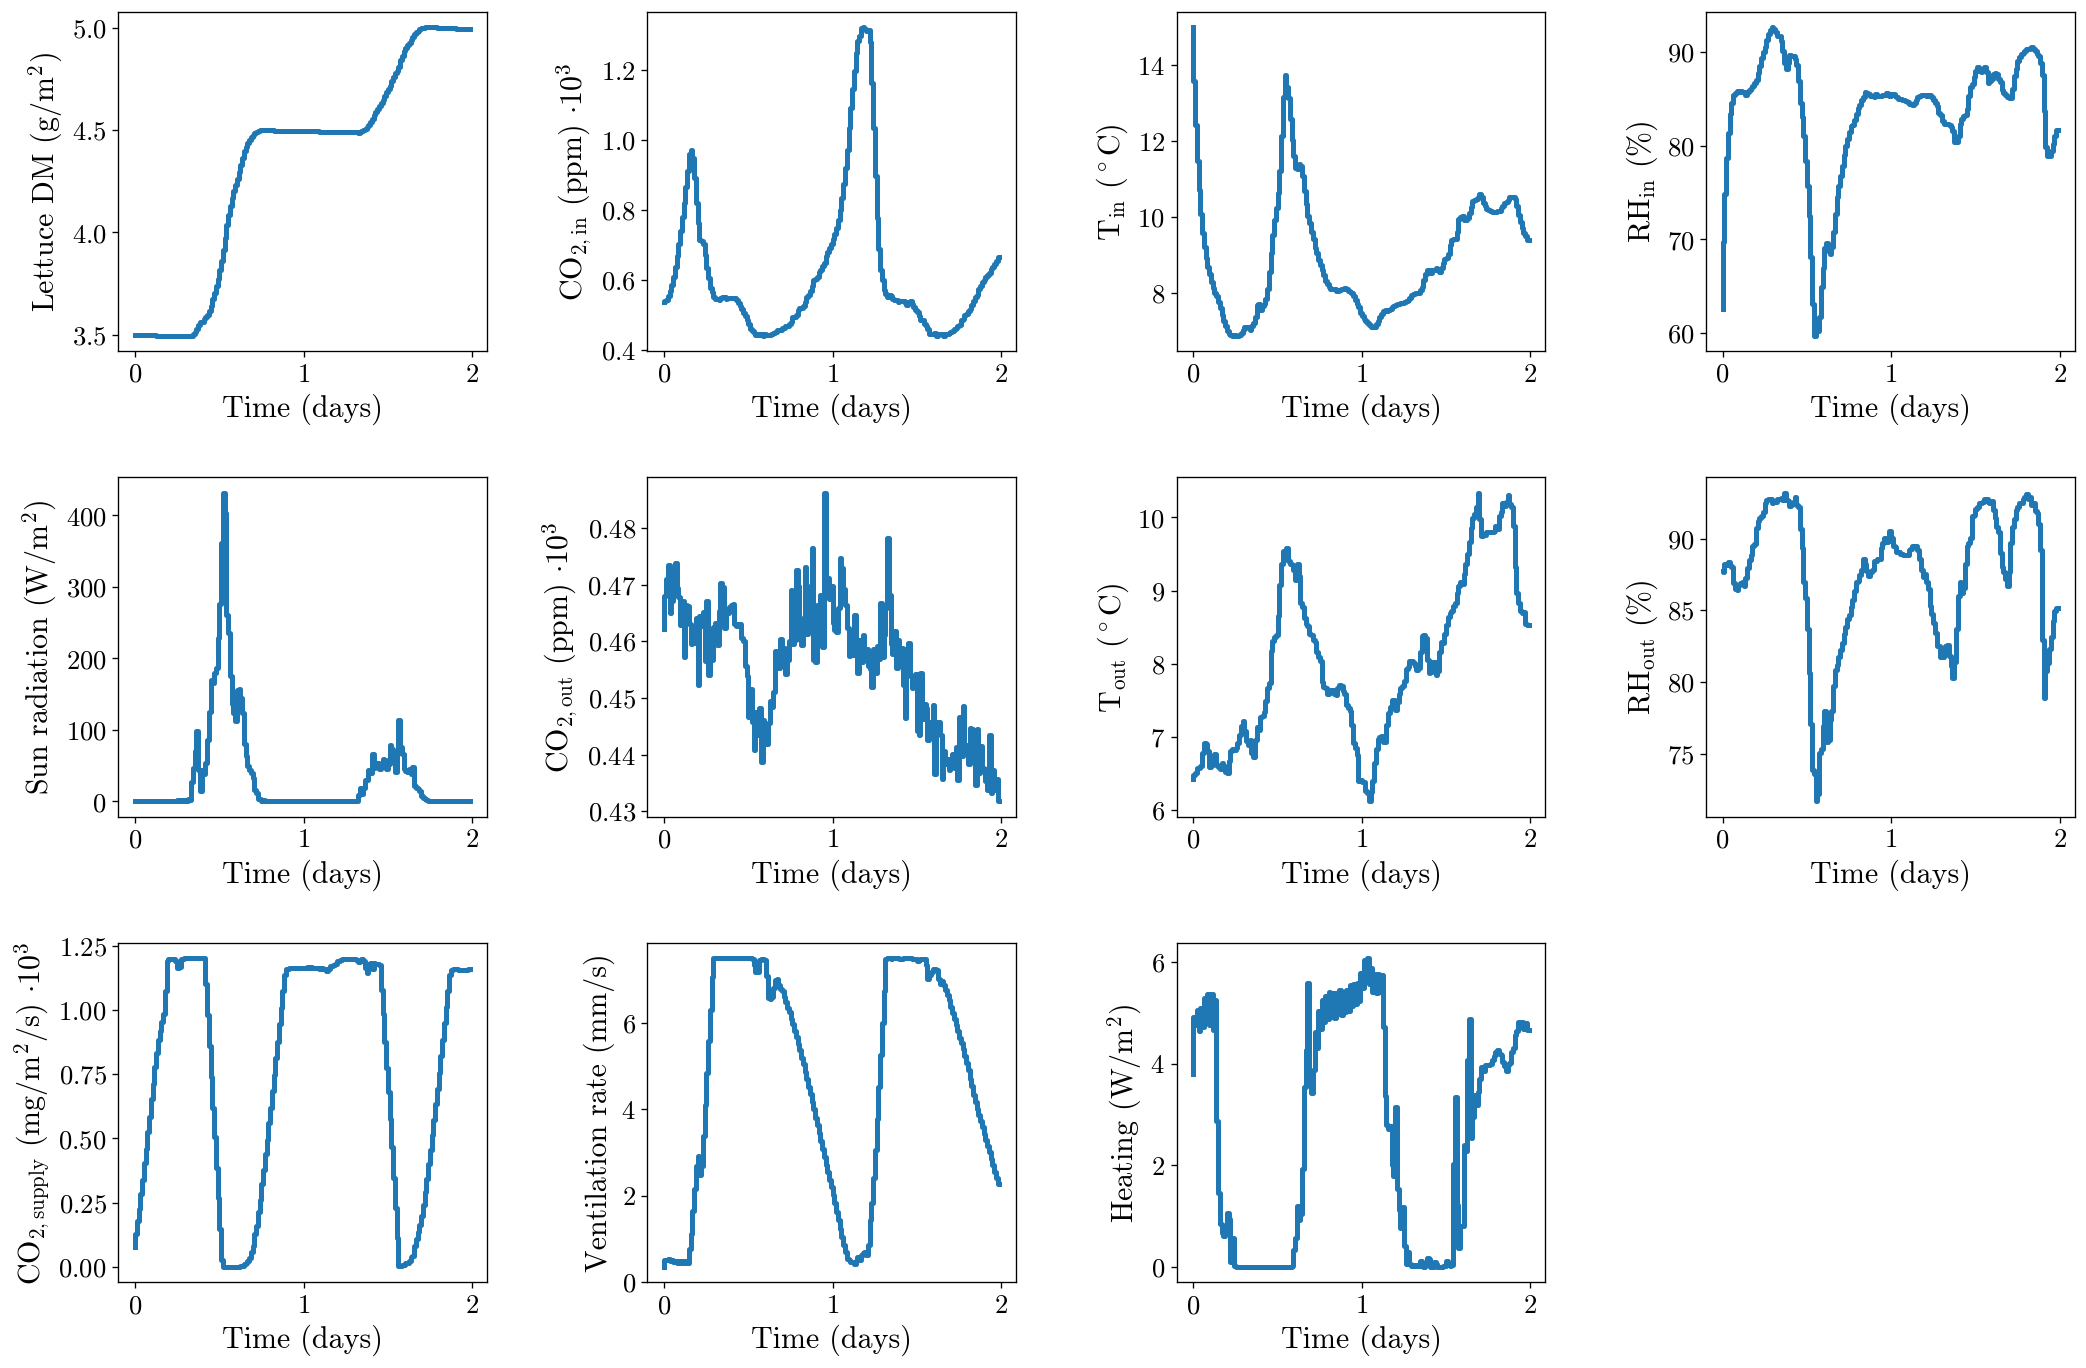

In [36]:
print("Plotting results...")

nvars = 11
# plot the resulting trajectory
n_per_day = int(24*3600/env.h) # control frequency per day
label= 'Trained SAC policy'
trajectory = np.concatenate((y, d, u), axis=1)
fig, axes = create_trajectory_figure(nvars, env.L, env.h, env.c, None, None)
fig, axes = plot_trajectory(fig, axes, trajectory, env.L, env.h, env.c, 0, env.n_days, n_per_day, label)